In [3]:
import numpy as np

def cos_similarity(v1, v2):
    # 두 벡터의 내적
    dot_product = np.dot(v1, v2)

    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2))))
    similarity = dot_product / l2_norm
    return similarity


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends' ,
            'if you take the red pill, you stay in Wonderland',
            'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [7]:
type(feature_vect_simple)

scipy.sparse._csr.csr_matrix

In [11]:
# TfidfVectorizer로 transform()한 결과는 Sparse Matrix 이므로 Dense Matrix로 변환
feature_vect_dense = feature_vect_simple.todense()

# 첫번째 문장과 두번째 문장의 feature vector 추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)

# 첫번째 문장과 두번째 문장의 feature vector로 두개 문장의 Cosine 유사도 추출
similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도 {0:.3f}'.format(similarity_simple))


문장 1, 문장 2 Cosine 유사도 0.402


In [14]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)

# 첫번째 문장과 두번째 문장의 feature vector로 두개 문장의 Cosine 유사도 추출
similarity_simple = cos_similarity(vect1, vect3)
print('문장 1, 문장 3 Cosine 유사도 {0:.3f}'.format(similarity_simple))


vect2 = np.array(feature_vect_dense[1]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)

# 첫번째 문장과 두번째 문장의 feature vector로 두개 문장의 Cosine 유사도 추출
similarity_simple = cos_similarity(vect2, vect3)
print('문장 2, 문장 3 Cosine 유사도 {0:.3f}'.format(similarity_simple))


문장 1, 문장 3 Cosine 유사도 0.404
문장 2, 문장 3 Cosine 유사도 0.456


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

# 첫번째 문장과 전체 문장 비교
similarity_simple_pair =cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [18]:
# 첫번째 문장과 두번째, 세번째 문장 비교 (자기 자신 제외)
similarity_simple_pair =cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [20]:
similarity_simple_pair =cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print(similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
(3, 3)


In [21]:
from nltk.stem import WordNetLemmatizer
import nltk
import string

remove_punct_dict = dict((ord(punct), None) for punct in string.punctuation)
lemmar = WordNetLemmatizer()

# 입력으로 들어온 token 단어들에 대해서 lemmatization 어근 변환
def LemTokens(tokens):
    return [lemmar.lemmatize(token) for token in tokens]

# 입력으로 문장을 받아서 stop words 제거 -> 소문자 변환 -> 단어 토큰화 -> lemmatization 어근 변환
def LemNormalize(text):
    return LemTokens(nltk.word_tokenize(text.lower().translate(remove_punct_dict)))


In [24]:
import glob, os
import pandas as pd
from sklearn.cluster import KMeans

path = '/Users/songbeom/PythonWorkSpace/machineLearning/perfect_guide/8장/topics'
all_files = glob.glob(os.path.join(path, '*.data'))

filename_list = []
opinion_text = []

for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')

    # 절대경로로 주어진 file 명을 가공 -> 맨 마지막 확장자를 제거해줍니다.
    filename = file_.split('/')[-1].split('.')[0]

    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가합니다.
    filename_list.append(filename)
    opinion_text.append(df.to_string())

# DataFrame 형태로 생성해줍니다.
document_df = pd.DataFrame({'filename' : filename_list, 'opinion_text' : opinion_text})
tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                             ngram_range=(1, 2), min_df=0.05, max_df=0.85)

feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_center = km_cluster.cluster_centers_
document_df['cluster_label'] = cluster_label
document_df.head(51)

/Users/songbeom/PythonWorkSpace/machineLearning/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/Users/songbeom/PythonWorkSpace/machineLearning/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


,filename,opinion_text,cluster_label
0,battery-life_ipod_nano_8gb,...,1
1,gas_mileage_toyota_camry_2007,...,2
2,room_holiday_inn_london,...,0
3,location_holiday_inn_london,...,0
4,staff_bestwestern_hotel_sfo,...,0
5,voice_garmin_nuvi_255W_gps,...,1
6,speed_garmin_nuvi_255W_gps,...,1
7,size_asus_netbook_1005ha,...,1
8,screen_garmin_nuvi_255W_gps,...,1
9,battery-life_amazon_kindle,...,1


In [30]:
hotel_indexes = document_df[document_df['cluster_label'] == 0].index
hotel_indexes

Index([2, 3, 4, 13, 16, 17, 20, 27, 28, 30, 31, 32, 39, 46, 49, 50], dtype='int64')

In [27]:
feature_vect.shape

(51, 4610)

In [34]:
from sklearn.metrics.pairwise import cosine_similarity

# cluster_label = 0인 데이터는 호텔로 클러스터링된 데이터임, DataFrame에서 해당 index 추출
hotel_indexes = document_df[document_df['cluster_label'] == 0].index
print('호텔로 클러스터링 된 문서들의 DataFrame index : {0}'.format(hotel_indexes))

# 호텔로 클러스터링된 데이터 중 첫번째 문서를 추출하여 파일명 표시
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('기준 문서 :',comparison_docname)

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame index : Index([2, 3, 4, 13, 16, 17, 20, 27, 28, 30, 31, 32, 39, 46, 49, 50], dtype='int64')
기준 문서 : room_holiday_inn_london
[[1.         0.19916545 0.22235033 0.37630751 0.26026921 0.15836819
  0.19544032 0.40020948 0.31125037 0.77331633 0.51442565 0.15023919
  0.16748876 0.81484793 0.11154242 0.10831518]]


[[13  9 10  7  3  8  4  2  1  6 12  5 11 14 15]]


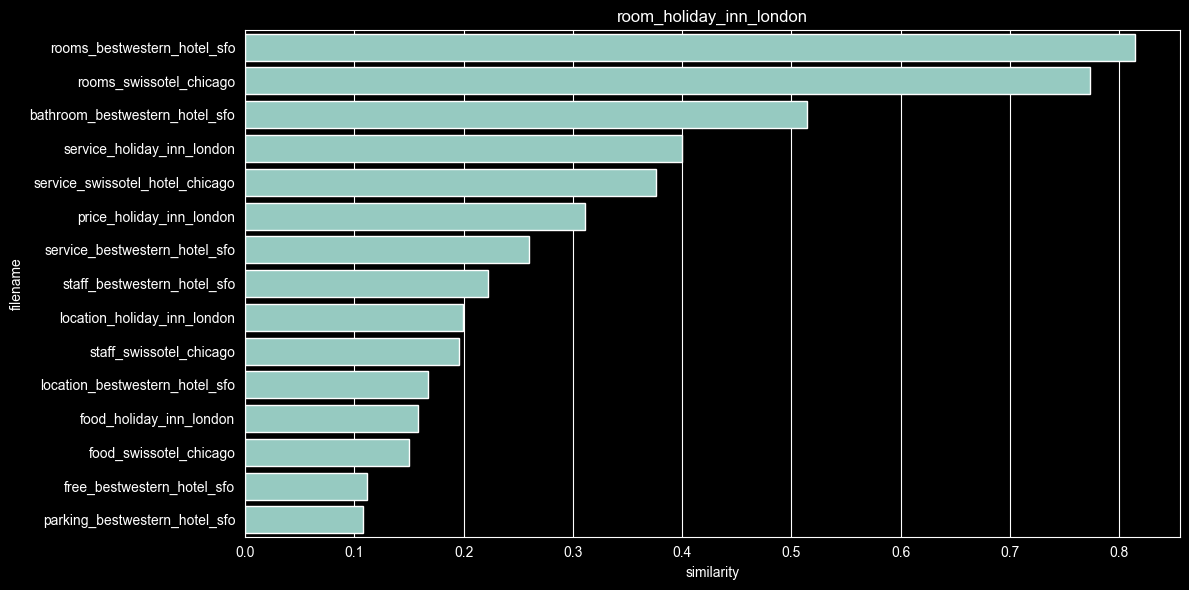

In [52]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]
print(sorted_index)

hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value
hotel_1_sim_df.iloc[0, :]

plt.figure(figsize=(12, 6))
sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)
plt.tight_layout()